in actual lab, due to pen size of drawing laser is larger than resultion, this file is used to generate the adapted files for production

(1024, 1024)


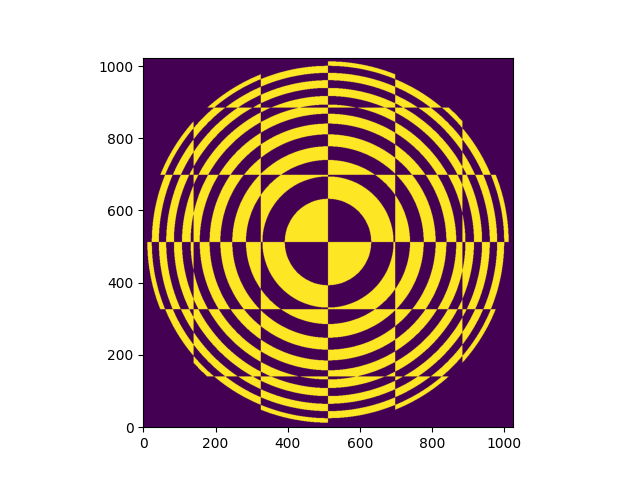

(1024, 1024)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import src.math_tool as mt
import src.img_tool as it
import src.apertures as apertures
from PIL import Image
%load_ext autoreload
%autoreload 2
%matplotlib widget
ideal_pattern = np.array(Image.open('aperture/quad_f35_1024.bmp'))
circle_d2 = np.array([[1, 1, 1],                                                # effective pen size is marked by 0
                      [1, 0, 0],
                      [1, 0, 0]]).astype(bool)
ellipse_x10y1 = np.array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
                          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
                          [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
                          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]).astype(bool).T

ellipse_x10y2 = np.array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
                          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
                          [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                          [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]).astype(bool).T

ellipse_x10y4 = np.array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
                          [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                          [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                          [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                          [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]).astype(bool).T
def cal(ideal_pattern, kernel_corner):
    def corrosive_kernel_func(arr): # return False if any pixel in range is False
        tmp = arr + kernel_corner
        return tmp.min(axis=(-1, -2))
    def constructive_kernel_func(arr): # return True if any pixel in range is True
        tmp = arr * (kernel_corner==False)
        return tmp.max(axis=(-1, -2))
    pad_x, pad_y = kernel_corner.shape
    pad_x//=2
    pad_y//=2
    tmp = it.img_pad(ideal_pattern, N_pad_xy=(pad_x, pad_x, pad_y, pad_y), pad_val=False)
    fab_file = it.conv_lambda2D(tmp, kernel_shape=kernel_corner.shape, f=corrosive_kernel_func)
    tmp = it.img_pad(fab_file, N_pad_xy=(pad_x, pad_x, pad_y, pad_y), pad_val=False)
    product = it.conv_lambda2D(tmp, kernel_shape=kernel_corner.shape, f=constructive_kernel_func)
    diff = product*1 - ideal_pattern*1
    return fab_file, product, diff
print(ideal_pattern.shape)
plt.imshow(ideal_pattern.T)
plt.gca().invert_yaxis()
plt.show()
print(ideal_pattern.shape)

In [14]:
fab_file, product, diff = cal(ideal_pattern, ellipse_x10y1)
#fab_file, product, diff = cal(ideal_pattern, circle_d4)

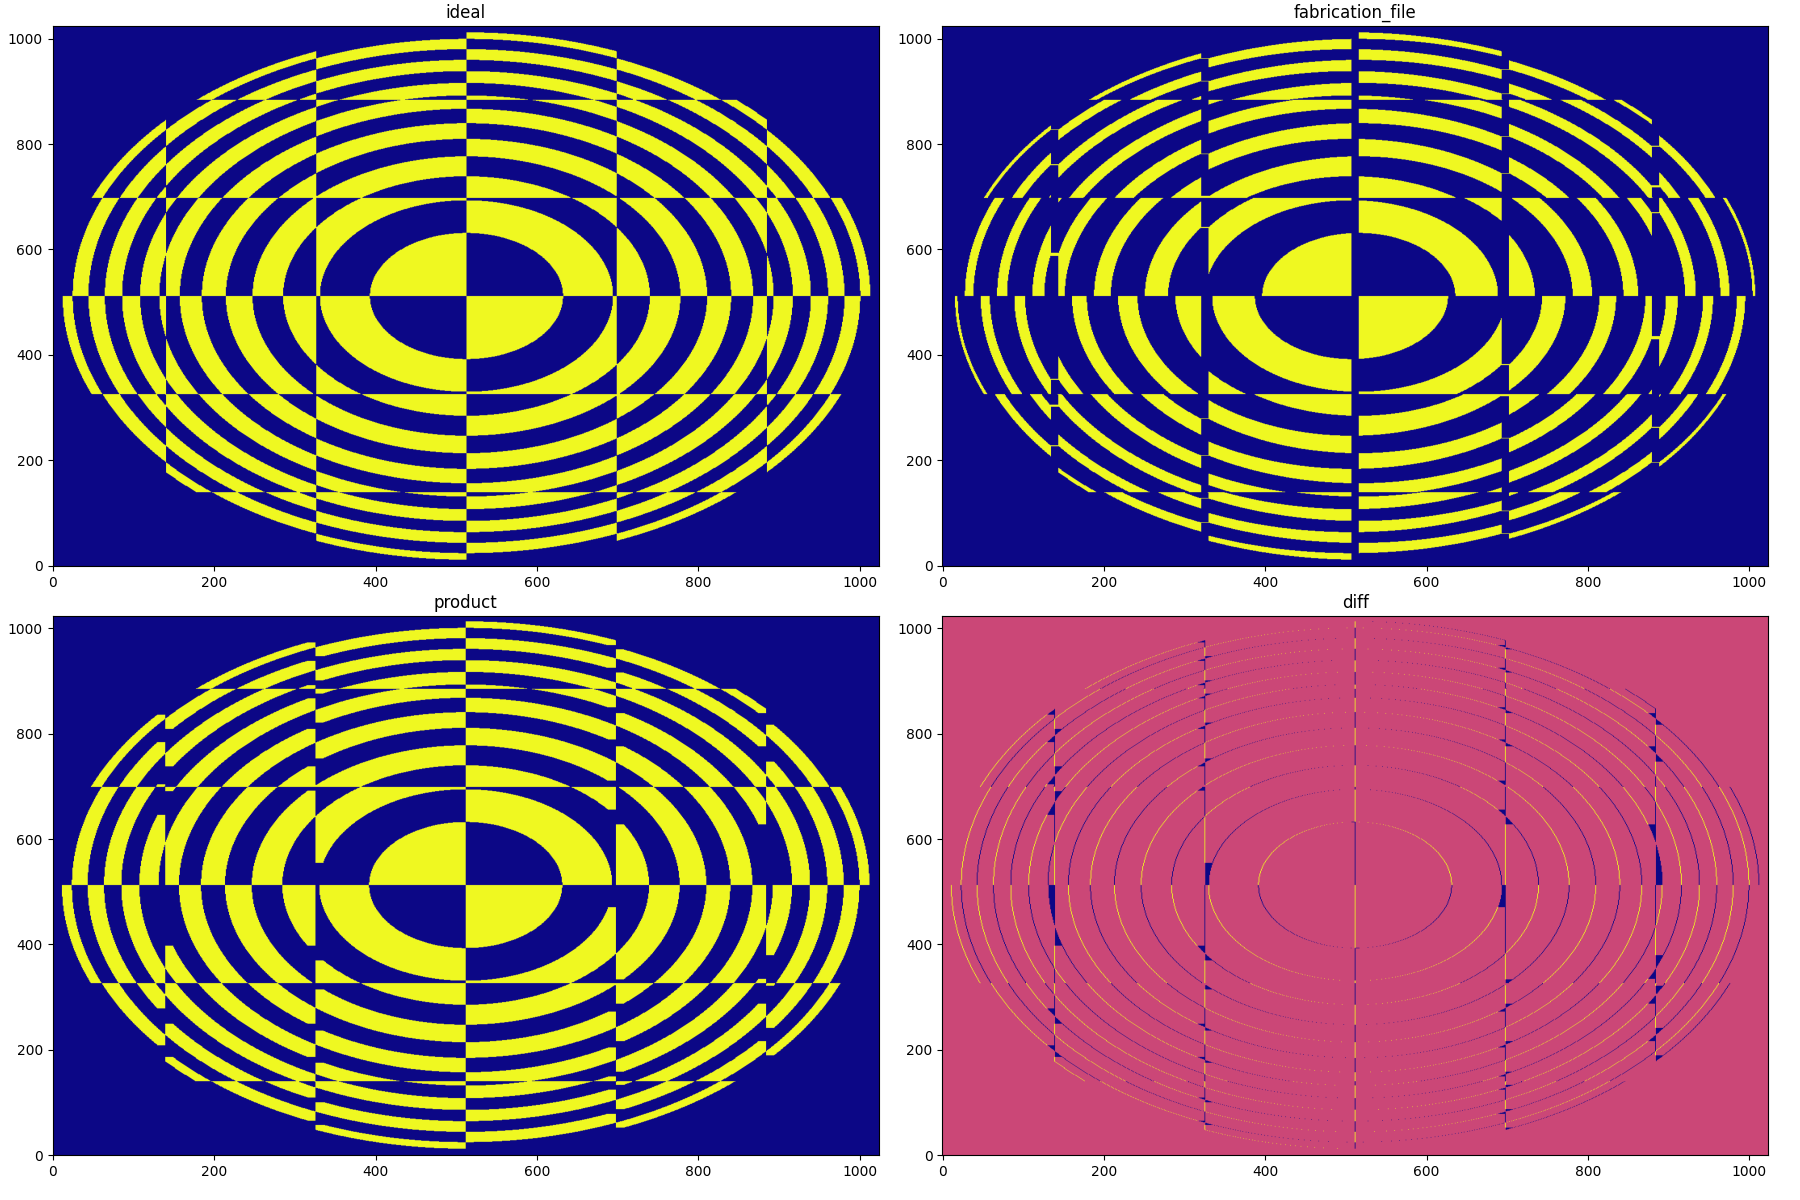

In [15]:
plt.clf()
layout = [[0, 1], [2, 3]]
fig, ax = plt.subplot_mosaic(layout, figsize=(18,12))
title = ['ideal', 'fabrication_file', 'product', 'diff']
image = [ideal_pattern, fab_file, product, diff]
fig.tight_layout(pad=1.5)
for i in range(len(title)):
    ax[i].imshow(image[i].T, aspect='auto', cmap='plasma')
    ax[i].invert_yaxis()
    ax[i].set_title(title[i])

In [16]:
print(f'similarity: {(diff==0).mean()*100}%')
num_diff = (diff!=0).sum()
print(f'num diff pixels: {num_diff}')

similarity: 97.57499694824219%
num diff pixels: 25428


In [17]:
fab_name = f'quad_f35_1000_fab_x10y1_inverted_d{num_diff}'
ver_name = f'quad_f35_1024_fab_x10y1_verify_d{num_diff}_padx2'
fab_file_output = (fab_file[12:-12, 12:-12]==False) # moidfy if file resolution (micron per pixel) change
it.array_2_img(fab_file_output, f'./aperture/tmp/{fab_name}.bmp')
product2 = product.copy()
# product2 = np.repeat(product2, 2, axis=0)
# product2 = np.repeat(product2, 2, axis=1)
product2 = it.img_pad(product2, N_pad_xy=(512, 512, 512, 512), pad_val=False)
print(product2.shape)
it.array_2_img(product2, f'./aperture/tmp/{ver_name}.bmp')

(2048, 2048)
